In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
dataset=pd.read_csv('/content/Drugs_Performance.csv')

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         84 non-null     int64  
 1   Drugs_Perf  84 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 1.4 KB


In [ ]:
dataset.describe()

,Age,Drugs_Perf
count,84.000000,84.000000
mean,42.500000,406.944444
std,24.392622,360.568584
min,1.000000,1.166667
25%,21.750000,83.333333
50%,42.500000,309.000000
75%,63.250000,678.166667
max,84.000000,1190.833333


In [ ]:
dataset.head()

,Age,Drugs_Perf
0,1,1.166667
1,2,1.833333
2,3,2.833333
3,4,4.166667
4,5,5.833333


In [ ]:
dataset.shape

(84, 2)

In [ ]:
dataset.isnull().sum()

NameError: name 'dataset' is not defined

In [ ]:
# Check duplicate records
print(dataset.duplicated().sum())
# Remove duplicates if any
dataset.drop_duplicates(inplace=True)

0


<Axes: ylabel='Drugs_Perf'>

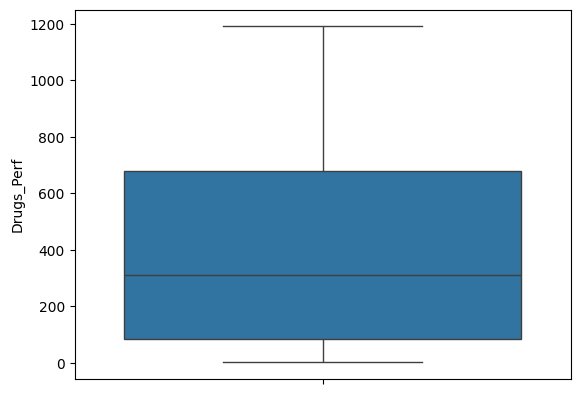

In [ ]:
#Outlier detection
sns.boxplot(dataset['Drugs_Perf'])

In [ ]:
#Independent and Dependent Variables
x=dataset['Age']
y=dataset['Drugs_Perf']

Text(0, 0.5, 'Drugs_Perf')

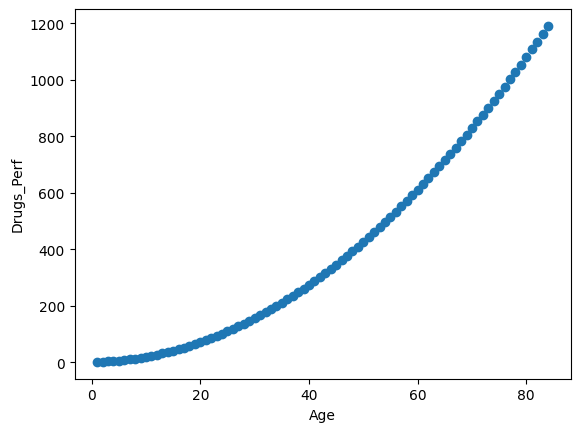

In [ ]:
plt.scatter(x,y)
plt.xlabel('Age')
plt.ylabel('Drugs_Perf')

In [ ]:
# Split the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Number of instances for training: {len(x_train)}")
print(f"Number of instances for testing: {len(x_test)}")

Number of instances for training: 67
Number of instances for testing: 17


In [ ]:
poly_features=PolynomialFeatures(degree=2)

In [ ]:
x_poly=poly_features.fit_transform(x.to_frame())

In [ ]:
lr_model=LinearRegression()
lr_model.fit(x_poly,y)

LinearRegression()

In [ ]:
model = LinearRegression()
x_train_poly = poly_features.transform(x_train.to_frame())
model.fit(x_train_poly, y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
x_test_poly = poly_features.transform(x_test.to_frame())
y_pred = lr_model.predict(x_test_poly)
df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
print(df)

         Actual    Predicted
73   925.833333   925.833333
0      1.166667     1.166667
58   590.833333   590.833333
22    92.833333    92.833333
12    31.166667    31.166667
70   852.833333   852.833333
10    22.833333    22.833333
18    64.166667    64.166667
4      5.833333     5.833333
65   737.833333   737.833333
40   287.833333   287.833333
47   392.833333   392.833333
35   222.833333   222.833333
81  1135.166667  1135.166667
55   532.833333   532.833333
54   514.166667   514.166667
33   199.166667   199.166667


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
y_train_pred = model.predict(x_train_poly)
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 5.7554079777323515e-08
Mean Squared Error (MSE): 8.565733286032597e-15
Root MSE (RMSE): 9.255124680971401e-08
R2 Score: 1.0


In [ ]:
# Evaluate model performance on testing data using MAE, MSE, RMSE, and R2 score
x_test_poly = poly_features.transform(x_test.to_frame())
y_test_pred = model.predict(x_test_poly)
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score: ", r2)

Mean Absolute Error (MAE): 5.738868721415295e-08
Mean Squared Error (MSE): 1.5538978270903727e-14
Root MSE (RMSE): 1.246554381922575e-07
R2 Score:  1.0


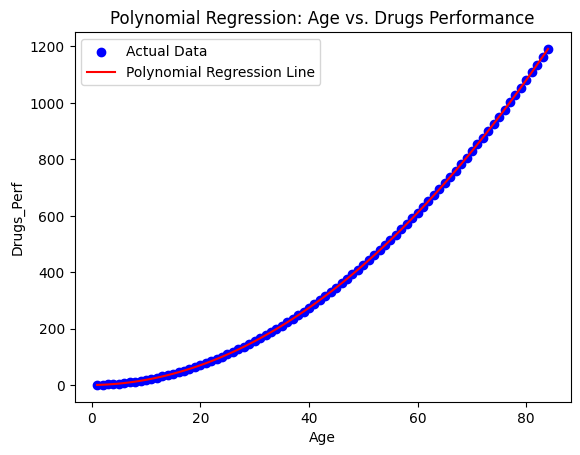

In [ ]:
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, model.predict(poly_features.transform(x.to_frame())), color='red', label='Polynomial Regression Line')
plt.xlabel('Age')
plt.ylabel('Drugs_Perf')
plt.title('Polynomial Regression: Age vs. Drugs Performance')
plt.legend()
plt.show()